In [ ]:
import psycopg2
import pandas as pd

# DB 연결 (안전 모드)
conn = psycopg2.connect(
    host="192.168.0.100",
    port=5432,
    dbname="GFCON_PSQL",
    user="postgres",
    password="0000",
    options="-c default_transaction_read_only=on"

)

# -----------------------------------------
# 1. 업체별 actual_wins / expected_wins 집계 SQL
#    - 공고×업체 중복 제거
#    - 참여업체수 N >= 10인 공고만 사용
# -----------------------------------------
sql = """
WITH bid_unique AS (
    SELECT DISTINCT
        b.bidntceno,
        b.bidprccorpbizrno,
        b.opengrank
    FROM data.bid b
),

notice_with_n AS (
    SELECT
        bu.bidntceno,
        COUNT(DISTINCT bu.bidprccorpbizrno) AS N_count
    FROM bid_unique bu
    GROUP BY bu.bidntceno
),

valid_notice AS (
    SELECT
        nw.bidntceno,
        nw.N_count
    FROM notice_with_n nw
    WHERE nw.N_count >= 10         -- 참여업체수 10개 이상 공고만 사용
),

bid_valid AS (
    SELECT
        bu.bidntceno,
        bu.bidprccorpbizrno,
        bu.opengrank,
        vn.N_count,
        1.0 / vn.N_count AS expected_prob,
        CASE
            WHEN TRIM(bu.opengrank::text) = '1' THEN 1
            ELSE 0
        END AS is_win
    FROM bid_unique bu
    JOIN valid_notice vn
      ON bu.bidntceno = vn.bidntceno
),

company_stats AS (
    SELECT
        bv.bidprccorpbizrno                         AS corp_id,
        COUNT(*)                                    AS total_bids,
        SUM(bv.is_win)                              AS actual_wins,
        SUM(bv.expected_prob)                       AS expected_wins
    FROM bid_valid bv
    GROUP BY bv.bidprccorpbizrno
)

SELECT
    cs.corp_id,
    cs.total_bids,
    cs.actual_wins,
    cs.expected_wins
FROM company_stats cs
WHERE cs.total_bids    >= 10     -- 최소 10회 이상 투찰한 업체만
  AND cs.expected_wins >  0;     -- 방어적 조건
"""

# -----------------------------------------
# 2. SQL 결과를 pandas로 읽기
# -----------------------------------------
df = pd.read_sql_query(sql, conn)

# 연결 닫기 (선택)
conn.close()

print("조회된 업체 수:", len(df))

# -----------------------------------------
# 3. performance_lift 계산
#    = 실제 낙찰횟수 / (Σ 1/N)
# -----------------------------------------
df['performance_lift'] = df['actual_wins'] / df['expected_wins']

# NaN / inf 방어 (0 나누기 등 혹시 모를 문제)
df = df.replace([float('inf'), float('-inf')], pd.NA).dropna(subset=['performance_lift'])

# -----------------------------------------
# 4. 상위 10, 20, 30, 50% 커트라인 계산
# -----------------------------------------
quantiles = df['performance_lift'].quantile([0.90, 0.80, 0.70, 0.50])
top_10_cut = quantiles.loc[0.90]
top_20_cut = quantiles.loc[0.80]
top_30_cut = quantiles.loc[0.70]
top_50_cut = quantiles.loc[0.50]

print(f"\n[Performance Lift 퍼센타일 커트라인]")
print(f"- 상위 10% (90th): {top_10_cut:.3f}")
print(f"- 상위 20% (80th): {top_20_cut:.3f}")
print(f"- 상위 30% (70th): {top_30_cut:.3f}")
print(f"- 상위 50% (50th, median): {top_50_cut:.3f}")

# -----------------------------------------
# 5. 성과 좋은 순으로 상위 몇 개 미리 보기
# -----------------------------------------
df_sorted = df.sort_values('performance_lift', ascending=False)

print("\n[성과 상위 10개 업체 예시]")
print(df_sorted.head(10))

# 필요하면 특정 구간만 따로
top10_df = df_sorted[df_sorted['performance_lift'] >= top_10_cut]
top20_df = df_sorted[df_sorted['performance_lift'] >= top_20_cut]
top30_df = df_sorted[df_sorted['performance_lift'] >= top_30_cut]
top50_df = df_sorted[df_sorted['performance_lift'] >= top_50_cut]

print(f"\n상위 10% 업체 수: {len(top10_df)}")
print(f"상위 20% 업체 수: {len(top20_df)}")
print(f"상위 30% 업체 수: {len(top30_df)}")
print(f"상위 50% 업체 수: {len(top50_df)}")


C:\Users\gfc\AppData\Local\Temp\ipykernel_4136\219391187.py:84: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


Trying to connect to Database...
✅ DB Connected Successfully!
Executing Query (Fetching data)...


C:\Users\gfc\AppData\Local\Temp\ipykernel_16528\3179653041.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


✅ Data Loaded: 143,307 rows


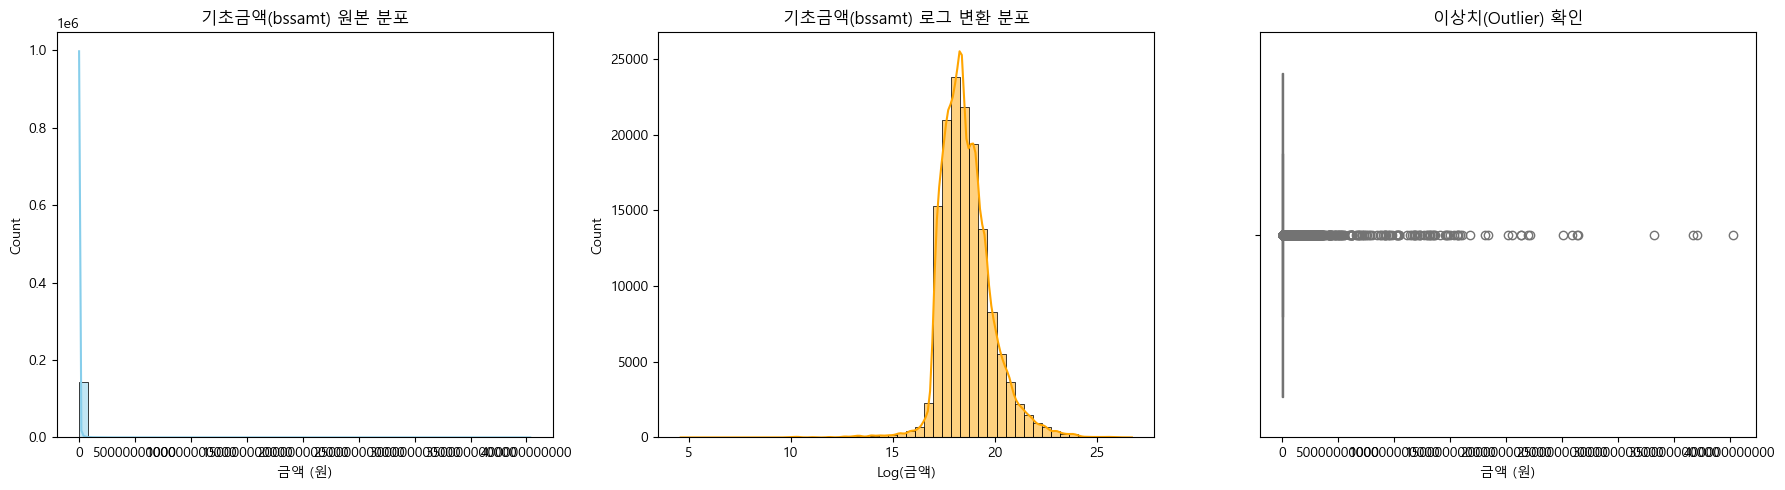


📊 [bssamt] 기초 통계량 요약
count           143,307
mean        465,068,009
std       4,117,401,939
min                 100
10%          32,689,200
25%          52,628,000
50%         100,000,000
75%         232,653,000
90%         579,888,200
99%       5,667,418,260
max     403,401,651,000
Name: bssamt, dtype: float64

💡 해석 팁:
1. 평균(mean)이 중앙값(50%)보다 훨씬 크다면, 초고가 공고가 존재한다는 뜻입니다.
2. 로그 변환 그래프(가운데)가 종 모양이라면, 모델 학습 시 'Log 변환'을 꼭 적용하세요.


In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. DB 연결 (안전 모드: Read Only)
# -----------------------------------------------------------
conn_params = {
    "host": "192.168.0.100",
    "port": 5432,
    "dbname": "GFCON_PSQL",
    "user": "postgres",
    "password": "0000",
    "options": "-c default_transaction_read_only=on"
}

print("Trying to connect to Database...")
try:
    with psycopg2.connect(**conn_params) as conn:
        print("✅ DB Connected Successfully!")
        
        # 2. 데이터 추출 SQL 실행
        # bssamt(기초금액)가 0보다 크고, 최근 3년 데이터(2022년~)만 가져옵니다.
        # 데이터가 200만 건이므로, 분석에 불필요한 과거 데이터나 0원은 DB단에서 거릅니다.
        sql = """
            SELECT bssamt
            FROM data.notice
            WHERE bidntcedt >= '2024-01-01' 
              AND bssamt > 0
        """
        
        print("Executing Query (Fetching data)...")
        df = pd.read_sql(sql, conn)
        print(f"✅ Data Loaded: {len(df):,} rows")

except Exception as e:
    print(f"❌ DB Connection Error: {e}")
    # 에러 발생 시 여기서 종료
    exit()

# -----------------------------------------------------------
# 3. 데이터 시각화 (분포 확인)
# -----------------------------------------------------------
# 한글 폰트 설정 (Windows 기준 'Malgun Gothic', Mac은 'AppleGothic' 변경 필요)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# (1) 원본 분포 (Original)
# 금액 데이터는 꼬리가 매우 길어서(Skewed) 막대 하나만 보일 가능성이 높음
sns.histplot(df['bssamt'], bins=50, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('기초금액(bssamt) 원본 분포')
ax[0].set_xlabel('금액 (원)')
ax[0].ticklabel_format(style='plain', axis='x') # 1e9 지수표현 끄기

# (2) 로그 변환 분포 (Log Scale) - ★핵심 분석 지표★
# 이 그래프가 정규분포(종 모양)에 가까워야 모델 학습이 잘 됩니다.
sns.histplot(np.log1p(df['bssamt']), bins=50, kde=True, ax=ax[1], color='orange')
ax[1].set_title('기초금액(bssamt) 로그 변환 분포')
ax[1].set_xlabel('Log(금액)')

# (3) 박스플롯 (이상치 확인)
sns.boxplot(x=df['bssamt'], ax=ax[2], color='lightgreen')
ax[2].set_title('이상치(Outlier) 확인')
ax[2].set_xlabel('금액 (원)')
ax[2].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 4. 요약 통계량 출력
# -----------------------------------------------------------
# 과학적 표기법(1.2e+08) 대신 실제 숫자(120,000,000)로 보기 위해 포맷팅
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')

print("\n" + "="*40)
print("📊 [bssamt] 기초 통계량 요약")
print("="*40)
# 주요 분위수(10%, 25%, 50%, 75%, 90%, 99%) 확인
stats = df['bssamt'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99])
print(stats)

print("\n" + "="*40)
print("💡 해석 팁:")
print("1. 평균(mean)이 중앙값(50%)보다 훨씬 크다면, 초고가 공고가 존재한다는 뜻입니다.")
print("2. 로그 변환 그래프(가운데)가 종 모양이라면, 모델 학습 시 'Log 변환'을 꼭 적용하세요.")
print("="*40)

In [3]:
import psycopg2
import pandas as pd

# ============================
# 0. 설정: 최근 3년 시작일
# ============================
# bidntcedt 가 'YYYYMMDD' 형식의 문자 컬럼이라고 가정
RECENT_START = "20230101"  # 필요하면 '20220101' 등으로 변경

# ============================
# 1. DB 연결
# ============================
conn = psycopg2.connect(
    host="192.168.0.100",
    port=5432,
    dbname="GFCON_PSQL",
    user="postgres",
    password="0000",
    options="-c default_transaction_read_only=on"
)

# ============================
# 2. 업체별 성과 집계 SQL
#    - 최근 3년 공고만 사용
#    - 공고×업체 중복 제거
#    - 참여업체수 N >= 10 공고만 사용
#    - 업체별 actual_wins / expected_wins 계산
# ============================
sql = f"""
WITH recent_notice AS (
    -- 최근 3년 공고만 추출
    SELECT n.bidntceno
    FROM data.notice n
    WHERE n.bidntcedt >= '{RECENT_START}'
),

bid_unique AS (
    -- 최근 3년 공고에 대해서만 공고-업체 단위로 1행만 남김
    SELECT
        b.bidntceno,
        b.bidprccorpbizrno,
        MIN(b.opengrank) AS opengrank
    FROM data.bid b
    JOIN recent_notice rn
      ON b.bidntceno = rn.bidntceno
    GROUP BY b.bidntceno, b.bidprccorpbizrno
),

notice_with_n AS (
    -- 공고별 참여업체 수 계산
    SELECT
        bu.bidntceno,
        COUNT(*) AS N_count
    FROM bid_unique bu
    GROUP BY bu.bidntceno
    HAVING COUNT(*) >= 10          -- 참여업체수 10개 이상 공고만 사용
),

bid_valid AS (
    -- 유효 공고에 대해 expected_prob(1/N), is_win 계산
    SELECT
        bu.bidntceno,
        bu.bidprccorpbizrno,
        bu.opengrank,
        nwn.N_count,
        1.0 / nwn.N_count AS expected_prob,
        CASE
            WHEN TRIM(bu.opengrank::text) = '1' THEN 1
            ELSE 0
        END AS is_win
    FROM bid_unique bu
    JOIN notice_with_n nwn
      ON bu.bidntceno = nwn.bidntceno
),

company_stats AS (
    -- 업체별 성과 집계
    SELECT
        bv.bidprccorpbizrno                         AS corp_id,
        COUNT(*)                                    AS total_bids,
        SUM(bv.is_win)                              AS actual_wins,
        SUM(bv.expected_prob)                       AS expected_wins
    FROM bid_valid bv
    GROUP BY bv.bidprccorpbizrno
)

SELECT
    cs.corp_id,
    cs.total_bids,
    cs.actual_wins,
    cs.expected_wins
FROM company_stats cs
WHERE cs.total_bids    >= 10      -- 최근 3년 유효 공고 기준 10회 이상 투찰
  AND cs.expected_wins >  0;      -- 방어적 조건
"""

# ============================
# 3. SQL 결과를 pandas로 읽기
# ============================
df = pd.read_sql_query(sql, conn)

# 연결 닫기 (원하면 나중에 다시 열어도 됨)
conn.close()

print("조회된 업체 수:", len(df))
print(df.head())

# ============================
# 4. performance_lift 계산
#    = 실제 낙찰횟수 / (Σ 1/N)
# ============================
df["performance_lift"] = df["actual_wins"] / df["expected_wins"]

# NaN / inf 방어
df = df.replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["performance_lift"])

# ============================
# 5. 상위 10, 20, 30, 50% 커트라인 계산
# ============================
quantiles = df["performance_lift"].quantile([0.90, 0.80, 0.70, 0.50])
top_10_cut = quantiles.loc[0.90]
top_20_cut = quantiles.loc[0.80]
top_30_cut = quantiles.loc[0.70]
top_50_cut = quantiles.loc[0.50]

print(f"\n[Performance Lift 퍼센타일 커트라인] (최근 3년, N>=10 공고 기준)")
print(f"- 상위 10% (90th): {top_10_cut:.3f}")
print(f"- 상위 20% (80th): {top_20_cut:.3f}")
print(f"- 상위 30% (70th): {top_30_cut:.3f}")
print(f"- 상위 50% (50th, median): {top_50_cut:.3f}")

# ============================
# 6. 성과 좋은 순으로 상위 몇 개 미리 보기
# ============================
df_sorted = df.sort_values("performance_lift", ascending=False)

print("\n[성과 상위 10개 업체 예시]")
print(df_sorted.head(10))

# 필요하면 특정 구간만 따로 뽑을 수 있음
top10_df = df_sorted[df_sorted["performance_lift"] >= top_10_cut]
top20_df = df_sorted[df_sorted["performance_lift"] >= top_20_cut]
top30_df = df_sorted[df_sorted["performance_lift"] >= top_30_cut]
top50_df = df_sorted[df_sorted["performance_lift"] >= top_50_cut]

print(f"\n상위 10% 업체 수: {len(top10_df)}")
print(f"상위 20% 업체 수: {len(top20_df)}")
print(f"상위 30% 업체 수: {len(top30_df)}")
print(f"상위 50% 업체 수: {len(top50_df)}")


C:\Users\gfc\AppData\Local\Temp\ipykernel_16528\3136791604.py:100: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


조회된 업체 수: 92837
      corp_id  total_bids  actual_wins  expected_wins
0  3378600226        1783            3              3
1  7518103249         123            5              6
2  3528801849         275            0              1
3  5088102286        1654            1              2
4  4018129887         620            2              4

[Performance Lift 퍼센타일 커트라인] (최근 3년, N>=10 공고 기준)
- 상위 10% (90th): 1.974
- 상위 20% (80th): 1.516
- 상위 30% (70th): 1.253
- 상위 50% (50th, median): 0.876

[성과 상위 10개 업체 예시]
          corp_id  total_bids  actual_wins  expected_wins  performance_lift
34798  2198101145          20            1              0                98
58093  1208603362          14            1              0                58
84691  2108173036          23            2              0                54
84977  1138668687          22            1              0                44
12753  1178194936          30            1              0                39
58471  6988802574          26     

In [4]:
import psycopg2
import pandas as pd

# ============================
# 0. 설정: 분석 시작일 (없애도 됨)
# ============================
# notice 테이블의 bidntcedt 가 'YYYYMMDD' 문자 컬럼이라고 가정
START_DATE = "20240101"   # 전체 기간이면 이 변수 안 쓰고 WHERE 절 삭제

# ============================
# 1. DB 연결
# ============================
conn = psycopg2.connect(
    host="192.168.0.100",
    port=5432,
    dbname="GFCON_PSQL",
    user="postgres",
    password="0000",
    options="-c default_transaction_read_only=on"
)

# ============================
# 2. 공고별 참여업체수 N_count 계산 SQL
#    - data.notice + data.bid 사용
#    - 공고별로 COUNT(DISTINCT 업체)
# ============================
sql = f"""
WITH notice_stats AS (
    SELECT
        n.bidntceno,
        COUNT(DISTINCT b.bidprccorpbizrno) AS n_count
    FROM data.notice n
    JOIN data.bid b
      ON b.bidntceno = n.bidntceno
    WHERE n.bidntcedt >= '{START_DATE}'   -- 필요 없으면 이 줄 삭제
    GROUP BY n.bidntceno
)
SELECT n_count
FROM notice_stats;
"""

# ============================
# 3. SQL 결과를 pandas로 읽기
# ============================
df = pd.read_sql_query(sql, conn)
conn.close()

print("분석 대상 공고 수:", len(df))
print(df.head())

# ============================
# 4. 기본 통계 & 4분위수 확인
# ============================
print("\n[참여업체수 기본 통계(describe)]")
print(df["n_count"].describe())

# 4분위수 (Q1, Q2(중앙값), Q3)
quartiles = df["n_count"].quantile([0.25, 0.5, 0.75])
q1 = quartiles.loc[0.25]
q2 = quartiles.loc[0.50]  # median
q3 = quartiles.loc[0.75]

print("\n[참여업체수 4분위수]")
print(f"Q1 (25%): {q1:.2f}")
print(f"Q2 (50%, median): {q2:.2f}")
print(f"Q3 (75%): {q3:.2f}")

# ============================
# 5. 분포 대략 보기 (자주 나오는 참여업체수 TOP 10)
# ============================
print("\n[참여업체수 값 분포 상위 10개]")
print(df["n_count"].value_counts().sort_index().head(10))


C:\Users\gfc\AppData\Local\Temp\ipykernel_16528\1183143129.py:45: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


분석 대상 공고 수: 138783
   n_count
0      625
1     1498
2      820
3      293
4       37

[참여업체수 기본 통계(describe)]
count   138,783
mean        238
std         434
min           1
25%          21
50%          68
75%         258
max      11,335
Name: n_count, dtype: float64

[참여업체수 4분위수]
Q1 (25%): 21.00
Q2 (50%, median): 68.00
Q3 (75%): 258.00

[참여업체수 값 분포 상위 10개]
n_count
1     9910
2     1745
3     1364
4     1265
5     1351
6     1421
7     1508
8     1531
9     1408
10    1401
Name: count, dtype: int64


In [8]:
import psycopg2
import pandas as pd

# ============================
# 0. 날짜 기준 설정
# ============================
START_DATE = "20200101"   # 2020-01-01 이후 공고

# ============================
# 1. DB 연결
# ============================
conn = psycopg2.connect(
    host="192.168.0.100",
    port=5432,
    dbname="GFCON_PSQL",
    user="postgres",
    password="0000",
    options="-c default_transaction_read_only=on"
)

# ============================
# 2. 공고별 참여업체 수 집계 SQL
#    - 2020-01-01 이후 공고만
#    - 공고×업체 중복 제거 후 카운트
# ============================
sql = f"""
WITH notice_filtered AS (
    -- 2020-01-01 이후 공고만
    SELECT n.bidntceno
    FROM data.notice n
    WHERE n.bidntcedt >= '{START_DATE}'
),

bid_unique AS (
    -- 공고-업체 조합 중복 제거
    SELECT
        b.bidntceno,
        b.bidprccorpbizrno
    FROM data.bid b
    JOIN notice_filtered nf
      ON b.bidntceno = nf.bidntceno
    GROUP BY b.bidntceno, b.bidprccorpbizrno
),

notice_n AS (
    -- 공고별 참여업체 수
    SELECT
        bidntceno,
        COUNT(*) AS N_count
    FROM bid_unique
    GROUP BY bidntceno
)

SELECT
    bidntceno,
    N_count
FROM notice_n
;
"""

# ============================
# 3. pandas로 읽기
# ============================
df = pd.read_sql_query(sql, conn)
conn.close()

print("공고 수:", len(df))
print(df.head())

# ============================
# 4. 분포/요약 통계 보기
# ============================
print("\n[참여업체수 기본 통계]")
print(df["n_count"].describe())   # N_count → n_count 로 수정

q = df["n_count"].quantile([0.25, 0.5, 0.75])
print("\n[4분위수]")
print(f"Q1 (25%): {q.loc[0.25]:.2f}")
print(f"Q2 (50%, median): {q.loc[0.50]:.2f}")
print(f"Q3 (75%): {q.loc[0.75]:.2f}")


# ============================
# 5. 자주 등장하는 구간/값 보고싶을 때 (옵션)
# ============================

# (1) 참여업체 수 값별 공고 수 (예: N=1~30까지만)
freq = df["n_count"].value_counts().sort_index()
print("\n[참여업체 수별 공고 수 (일부)]")
print(freq.head(30))   # 상위 몇 개만

# (2) 히스토그램용 구간 빈도 (bins=10 예시)
bins = pd.cut(df["n_count"], bins=10, right=True, include_lowest=True)
hist_counts = bins.value_counts().sort_index()

print("\n[히스토그램 구간별 공고 수]")
print(hist_counts)

print("\n[bin 경계값]")
print(bins.cat.categories)



C:\Users\gfc\AppData\Local\Temp\ipykernel_16528\3228382740.py:64: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


공고 수: 711249
     bidntceno  n_count
0  20240530820      109
1  20231021384     2896
2  20200517786       29
3  20210616826      730
4  20240105304       28

[참여업체수 기본 통계]
count   711,249
mean        238
std         415
min           1
25%          23
50%          72
75%         274
max      11,696
Name: n_count, dtype: float64

[4분위수]
Q1 (25%): 23.00
Q2 (50%, median): 72.00
Q3 (75%): 274.00

[참여업체 수별 공고 수 (일부)]
n_count
1     25652
2      7256
3      7397
4      7455
5      8241
6      8797
7      8831
8      8350
9      7989
10     7652
11     7701
12     7113
13     6645
14     6678
15     6856
16     6696
17     6460
18     6484
19     6314
20     6329
21     6087
22     5909
23     5704
24     5415
25     5410
26     4989
27     4802
28     4508
29     4407
30     4412
Name: count, dtype: int64

[히스토그램 구간별 공고 수]
n_count
(-10.696, 1170.5]     688405
(1170.5, 2340.0]       17204
(2340.0, 3509.5]        5160
(3509.5, 4679.0]         306
(4679.0, 5848.5]          94
(5848.5, 7018.0]   

In [9]:
q99 = df["n_count"].quantile(0.99)
print("99퍼센타일:", q99)


99퍼센타일: 1656.0


In [10]:
upper = int(q99)  # 1656
df_focus = df[df["n_count"] <= upper]

print("필터링 후 공고 수:", len(df_focus))


필터링 후 공고 수: 704148


In [18]:
import numpy as np
import pandas as pd

step = 50  # 50개 단위 구간
bins = np.arange(0, upper + step, step)  # 0, 50, 100, ..., 1650, 1700

bins_cut = pd.cut(
    df_focus["n_count"],
    bins=bins,
    right=False,         # [a, b) 구간
    include_lowest=True  # 0도 포함
)

hist_counts = bins_cut.value_counts().sort_index()

print("\n[참여업체 수 구간별 공고 수 (0 ~ 99퍼센타일, 50단위)]")
print(hist_counts.head(30))  # 앞쪽 구간 예시



[참여업체 수 구간별 공고 수 (0 ~ 99퍼센타일, 50단위)]
n_count
[0, 50)         292315
[50, 100)       112250
[100, 150)       53723
[150, 200)       36819
[200, 250)       29007
[250, 300)       20698
[300, 350)       19579
[350, 400)       13885
[400, 450)       12680
[450, 500)       11232
[500, 550)        9393
[550, 600)        9768
[600, 650)        9865
[650, 700)        8555
[700, 750)        6828
[750, 800)        6898
[800, 850)        6704
[850, 900)        6322
[900, 950)        5018
[950, 1000)       5117
[1000, 1050)      3892
[1050, 1100)      3499
[1100, 1150)      3144
[1150, 1200)      2626
[1200, 1250)      2220
[1250, 1300)      1786
[1300, 1350)      1331
[1350, 1400)      1096
[1400, 1450)      1184
[1450, 1500)      1846
Name: count, dtype: int64


In [19]:
top_bin = hist_counts.idxmax()
top_bin_count = hist_counts.max()

print("\n[가장 공고가 많은 참여업체수 구간 (0~99퍼센타일 기준)]")
print(f"{top_bin} 구간에 공고 {top_bin_count}건")



[가장 공고가 많은 참여업체수 구간 (0~99퍼센타일 기준)]
[0, 50) 구간에 공고 292315건


In [20]:
df_0_50 = df_focus[(df_focus["n_count"] >= 0) & (df_focus["n_count"] < 50)]
print("0~50 구간 공고 수:", len(df_0_50))


0~50 구간 공고 수: 292315


In [14]:
import numpy as np

step = 5  # 5개 단위
bins = np.arange(0, 50 + step, step)   # 0,5,10,...50

bins_cut = pd.cut(
    df_0_50["n_count"],
    bins=bins,
    right=False,
    include_lowest=True
)

hist_counts_5 = bins_cut.value_counts().sort_index()

print("\n[참여업체 수 구간별 공고 수 (0~50, 5단위)]")
print(hist_counts_5)



[참여업체 수 구간별 공고 수 (0~50, 5단위)]
n_count
[0, 5)      47760
[5, 10)     42208
[10, 15)    35789
[15, 20)    32810
[20, 25)    29444
[25, 30)    24116
[30, 35)    22857
[35, 40)    21150
[40, 45)    18861
[45, 50)    17320
Name: count, dtype: int64


In [21]:
top_bin_5 = hist_counts_5.idxmax()
top_bin_5_count = hist_counts_5.max()

print("\n[0~50 세부 최빈 구간 (5단위)]")
print(f"{top_bin_5} 구간에 공고 {top_bin_5_count}건")



[0~50 세부 최빈 구간 (5단위)]
[0, 5) 구간에 공고 47760건


In [22]:
# 1) 전체 공고 수
total = hist_counts.sum()
print("총 공고 수:", total)

# 2) 누적 공고 수 & 누적 비율
cum_counts = hist_counts.cumsum()
cum_ratio = cum_counts / total

print("\n[구간별 누적 비율]")
print(cum_ratio)

# 3) 50%, 70%, 80% 지점이 되는 구간 찾기
targets = [0.5, 0.7, 0.8]

print("\n[누적 50%, 70%, 80%를 처음 넘는 참여업체수 구간]")
for t in targets:
    # 누적비율이 t 이상인 첫 번째 구간
    first_bin = cum_ratio[cum_ratio >= t].index[0]
    first_val = cum_ratio[cum_ratio >= t].iloc[0]
    print(f"{int(t*100)}% 지점: {first_bin} (누적비율={first_val:.3f})")




총 공고 수: 704148

[구간별 누적 비율]
n_count
[0, 50)        0
[50, 100)      1
[100, 150)     1
[150, 200)     1
[200, 250)     1
[250, 300)     1
[300, 350)     1
[350, 400)     1
[400, 450)     1
[450, 500)     1
[500, 550)     1
[550, 600)     1
[600, 650)     1
[650, 700)     1
[700, 750)     1
[750, 800)     1
[800, 850)     1
[850, 900)     1
[900, 950)     1
[950, 1000)    1
[1000, 1050)   1
[1050, 1100)   1
[1100, 1150)   1
[1150, 1200)   1
[1200, 1250)   1
[1250, 1300)   1
[1300, 1350)   1
[1350, 1400)   1
[1400, 1450)   1
[1450, 1500)   1
[1500, 1550)   1
[1550, 1600)   1
[1600, 1650)   1
[1650, 1700)   1
Name: count, dtype: float64

[누적 50%, 70%, 80%를 처음 넘는 참여업체수 구간]
50% 지점: [50, 100) (누적비율=0.575)
70% 지점: [150, 200) (누적비율=0.703)
80% 지점: [300, 350) (누적비율=0.802)


In [24]:

import psycopg2
import pandas as pd

# ============================
# 0. 날짜 기준 설정
# ============================
START_DATE = "20200101"   # 2020-01-01 이후 공고

# ============================
# 1. DB 연결
# ============================
conn = psycopg2.connect(
    host="192.168.0.100",
    port=5432,
    dbname="GFCON_PSQL",
    user="postgres",
    password="0000",
    options="-c default_transaction_read_only=on"
)

# ============================
# 2. 공고별 참여업체 수 집계 SQL
# ============================
sql_notice_n = f"""
WITH notice_filtered AS (
    -- 2020-01-01 이후 공고만
    SELECT n.bidntceno
    FROM data.notice n
    WHERE n.bidntcedt >= '{START_DATE}'
),

bid_unique AS (
    -- 공고-업체 조합 중복 제거
    SELECT
        b.bidntceno,
        b.bidprccorpbizrno
    FROM data.bid b
    JOIN notice_filtered nf
      ON b.bidntceno = nf.bidntceno
    GROUP BY b.bidntceno, b.bidprccorpbizrno
),

notice_n AS (
    -- 공고별 참여업체 수
    SELECT
        bidntceno,
        COUNT(*) AS n_count
    FROM bid_unique
    GROUP BY bidntceno
)

SELECT
    bidntceno,
    n_count
FROM notice_n
;
"""

# pandas로 읽기
df_notice = pd.read_sql_query(sql_notice_n, conn)

print("전체 공고 수 (2020 이후):", len(df_notice))
print(df_notice.head())
print(df_notice["n_count"].describe())


C:\Users\gfc\AppData\Local\Temp\ipykernel_16528\3412531119.py:60: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_notice = pd.read_sql_query(sql_notice_n, conn)


전체 공고 수 (2020 이후): 711249
     bidntceno  n_count
0  20240530820      109
1  20231021384     2896
2  20200517786       29
3  20210616826      730
4  20240105304       28
count   711,249
mean        238
std         415
min           1
25%          23
50%          72
75%         274
max      11,696
Name: n_count, dtype: float64


In [25]:
# 참여업체수 350 이하 공고만 필터링
MAX_N = 350
df_0_350 = df_notice[df_notice["n_count"] <= MAX_N].copy()

print("\n[참여업체수 ≤ 350 공고 필터링]")
print("공고 수:", len(df_0_350))
print(df_0_350["n_count"].describe())



[참여업체수 ≤ 350 공고 필터링]
공고 수: 564680
count   564,680
mean         80
std          86
min           1
25%          17
50%          47
75%         115
max         350
Name: n_count, dtype: float64


In [26]:
# 0~350 구간 공고번호 리스트
notice_ids_0_350 = df_0_350["bidntceno"].unique().tolist()
print("0~350 구간 공고 ID 개수:", len(notice_ids_0_350))

# ============================
# 3. 필터링된 공고들에 대해 공고-업체 데이터 가져오기
#    - 공고×업체 조합 중복 제거
# ============================
sql_bid_filtered = """
    SELECT
        b.bidntceno,
        b.bidprccorpbizrno
    FROM data.bid b
    WHERE b.bidntceno = ANY(%s)
"""

df_bid = pd.read_sql_query(sql_bid_filtered, conn, params=(notice_ids_0_350,))
print("\n[필터링된 공고들에 대한 bid 데이터]")
print(df_bid.head(), len(df_bid))

# 중복 제거 (공고×업체)
df_bid_unique = df_bid.drop_duplicates(subset=["bidntceno", "bidprccorpbizrno"])
print("중복 제거 후 행 수:", len(df_bid_unique))


0~350 구간 공고 ID 개수: 564680


C:\Users\gfc\AppData\Local\Temp\ipykernel_16528\872029246.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_bid = pd.read_sql_query(sql_bid_filtered, conn, params=(notice_ids_0_350,))



[필터링된 공고들에 대한 bid 데이터]
     bidntceno bidprccorpbizrno
0  20200930753       2258119918
1  20200930753       2248123457
2  20200930753       2258114679
3  20200930753       2258121864
4  20211210945       3038116583 45337535
중복 제거 후 행 수: 45337535


In [27]:
# 업체별 입찰 공고 수(= 해당 공고 풀에서 참여한 공고 개수)
company_bid_counts = (
    df_bid_unique
    .groupby("bidprccorpbizrno")
    .size()
    .rename("bid_count")
)

print("\n[업체별 입찰 공고 수 통계]")
print(company_bid_counts.describe())

avg_bid_count = company_bid_counts.mean()
median_bid_count = company_bid_counts.median()

print(f"\n0~{MAX_N} 구간 공고들 기준")
print(f"- 업체당 평균 입찰 공고 수: {avg_bid_count:.3f}")
print(f"- 업체당 입찰 공고 수 중앙값: {median_bid_count:.3f}")



[업체별 입찰 공고 수 통계]
count   108,125
mean        419
std         533
min           1
25%          54
50%         236
75%         580
max      22,274
Name: bid_count, dtype: float64

0~350 구간 공고들 기준
- 업체당 평균 입찰 공고 수: 419.307
- 업체당 입찰 공고 수 중앙값: 236.000


In [2]:
START_DATE = "20200101"

import psycopg2
import pandas as pd

# DB 연결 (안전 모드)
conn = psycopg2.connect(
    host="192.168.0.100",
    port=5432,
    dbname="GFCON_PSQL",
    user="postgres",
    password="0000",
    options="-c default_transaction_read_only=on"

)

sql_company_stats = f"""
WITH notice_filtered AS (
    -- 2020-01-01 이후 공고만
    SELECT n.bidntceno
    FROM data.notice n
    WHERE n.bidntcedt >= '{START_DATE}'
),

bid_unique AS (
    -- 공고-업체 조합 중복 제거
    SELECT
        b.bidntceno,
        b.bidprccorpbizrno,
        MIN(b.opengrank) AS opengrank
    FROM data.bid b
    JOIN notice_filtered nf
      ON b.bidntceno = nf.bidntceno
    GROUP BY b.bidntceno, b.bidprccorpbizrno
),

notice_n AS (
    -- 공고별 참여업체 수
    SELECT
        bidntceno,
        COUNT(*) AS n_count
    FROM bid_unique
    GROUP BY bidntceno
),

notice_0_350 AS (
    -- 참여업체수 350 이하 공고만
    SELECT bidntceno
    FROM notice_n
    WHERE n_count <= 350
),

bid_in_range AS (
    -- 해당 공고들에 대한 공고-업체-순위
    SELECT
        bu.bidntceno,
        bu.bidprccorpbizrno,
        bu.opengrank
    FROM bid_unique bu
    JOIN notice_0_350 nf
      ON bu.bidntceno = nf.bidntceno
),

company_stats AS (
    -- 업체별 입찰 공고 수 / 낙찰 횟수
    SELECT
        bidprccorpbizrno AS corp_id,
        COUNT(DISTINCT bidntceno) AS bid_count,
        SUM(CASE WHEN opengrank = 1 THEN 1 ELSE 0 END) AS win_count
    FROM bid_in_range
    GROUP BY bidprccorpbizrno
)

SELECT
    corp_id,
    bid_count,
    win_count,
    CASE 
        WHEN bid_count > 0 THEN win_count::float / bid_count
        ELSE NULL
    END AS win_rate
FROM company_stats
;
"""

df_company_stats = pd.read_sql_query(sql_company_stats, conn)
print("업체 수:", len(df_company_stats))
print(df_company_stats.describe())


C:\Users\gfc\AppData\Local\Temp\ipykernel_10944\4156764051.py:86: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_company_stats = pd.read_sql_query(sql_company_stats, conn)


업체 수: 108125
           bid_count      win_count       win_rate
count  108125.000000  108125.000000  108125.000000
mean      419.306682       5.152647       0.029305
std       532.509506       7.047443       0.107808
min         1.000000       0.000000       0.000000
25%        54.000000       0.000000       0.000000
50%       236.000000       3.000000       0.008929
75%       580.000000       7.000000       0.020576
max     22274.000000     233.000000       1.000000


In [5]:
top_quantiles = df_company_stats["win_rate"].quantile([0.95, 0.90, 0.80, 0.70])

print("\n[업체 낙찰률 상위 분위수]")
print(f"상위 5%  (95th) : {top_quantiles.loc[0.95]:.4f}")
print(f"상위 10% (90th) : {top_quantiles.loc[0.90]:.4f}")
print(f"상위 20% (80th) : {top_quantiles.loc[0.80]:.4f}")
print(f"상위 30% (70th) : {top_quantiles.loc[0.70]:.4f}")




[업체 낙찰률 상위 분위수]
상위 5%  (95th) : 0.0760
상위 10% (90th) : 0.0435
상위 20% (80th) : 0.0251
상위 30% (70th) : 0.0172


In [ ]:
# ... (이전 SQL 실행 및 데이터프레임 로드 코드와 동일)

df_company_stats = pd.read_sql_query(sql_company_stats, conn)

# 1. 전체 업체의 입찰 참여 횟수 평균 계산
mean_bid_count = df_company_stats['bid_count'].mean()
print(f"전체 업체 평균 투찰 횟수: {mean_bid_count:.2f}회")

# 2. 평균 이상 투찰한 업체만 필터링
df_filtered = df_company_stats[df_company_stats['bid_count'] >= mean_bid_count].copy()
print(f"필터링 후 업체 수: {len(df_filtered)} (전체 {len(df_company_stats)}개 중)")

# 3. 필터링된 업체들을 대상으로 낙찰률 상위 분위수 계산
top_quantiles = df_filtered["win_rate"].quantile([0.95, 0.90, 0.80, 0.70])

print("\n[평균 투찰 횟수 이상 업체의 낙찰률 상위 분위수]")
print(f"상위 5%  (95th) : {top_quantiles.loc[0.95]:.4f}")
print(f"상위 10% (90th) : {top_quantiles.loc[0.90]:.4f}")
print(f"상위 20% (80th) : {top_quantiles.loc[0.80]:.4f}")
print(f"상위 30% (70th) : {top_quantiles.loc[0.70]:.4f}")

C:\Users\gfc\AppData\Local\Temp\ipykernel_10944\707288376.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_company_stats = pd.read_sql_query(sql_company_stats, conn)


In [7]:
# 1. 전체 업체의 입찰 참여 횟수 평균 계산
median_bid_count = df_company_stats['bid_count'].median()
print(f"전체 업체 평균 투찰 횟수: {median_bid_count:.2f}회")

# 2. median 이상 투찰한 업체만 필터링
df_filtered = df_company_stats[df_company_stats['bid_count'] >= median_bid_count].copy()
print(f"필터링 후 업체 수: {len(df_filtered)} (전체 {len(df_company_stats)}개 중)")

# 3. 필터링된 업체들을 대상으로 낙찰률 상위 분위수 계산
top_quantiles = df_filtered["win_rate"].quantile([0.95, 0.90, 0.80, 0.70])

print("\n[평균 투찰 횟수 이상 업체의 낙찰률 상위 분위수]")
print(f"상위 5%  (95th) : {top_quantiles.loc[0.95]:.4f}")
print(f"상위 10% (90th) : {top_quantiles.loc[0.90]:.4f}")
print(f"상위 20% (80th) : {top_quantiles.loc[0.80]:.4f}")
print(f"상위 30% (70th) : {top_quantiles.loc[0.70]:.4f}")

전체 업체 평균 투찰 횟수: 236.00회
필터링 후 업체 수: 54098 (전체 108125개 중)

[평균 투찰 횟수 이상 업체의 낙찰률 상위 분위수]
상위 5%  (95th) : 0.0364
상위 10% (90th) : 0.0272
상위 20% (80th) : 0.0191
상위 30% (70th) : 0.0148
